In [2]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from sklearn.cluster import KMeans
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import r2_score
from typing import Sequence
from dataclasses import dataclass
from typing import NamedTuple
from typing import Mapping
from typing import TypeAlias
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.optimize import minimize

sys.path.append('C:/Users/evils/PycharmProjects/approximationMap')

from control.experiment_data import ExperimentData

In [3]:
"""АННОТАЦИЯ ТИПОВ"""
FuelCombination: TypeAlias = str

class ApproxData(NamedTuple):
    """Аппроксимированная поверхность со значением расхода топлива и вводимого компонента"""
    fuel_consumption: np.ndarray
    additive_consumption: np.ndarray
    approximated_surface: np.ndarray

class DiffData(NamedTuple):
    """Дифференциальная поверхность со значением расхода топлива и вводимого компонента"""
    fuel_consumption: np.ndarray
    additive_consumption: np.ndarray
    diff_surface: np.ndarray

class MinPoints(NamedTuple):
    """Координаты минимимальных значений каждой строки в матрице"""
    x: np.ndarray
    y: np.ndarray

class LinearCoeffs(NamedTuple):
    """Коэффициенты линейной прямой"""
    angular_coefficient: float  # Угловой коэффицент
    b: float

class LevelPoints(NamedTuple):
    """Координаты выбранного уровне contourf"""
    x: np.ndarray
    y: np.ndarray

"""ОШИБКИ"""

def fuel_combination_key_error() -> KeyError:
    return KeyError('Сочетание топлива, добавки и компонента не найдено в словаре!')

"""ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ"""

def get_fuels_combinations(CO=True) -> list[FuelCombination]:
    if CO:
        fuel_combinations = [
            'diesel_steam_CO',
            'crude_oil_steam_CO',
            'heavy_oil_steam_CO',
            'kerosene_steam_CO',
            'waste_oil_steam_CO',
            'waste_oil_40_2024_steam_CO',
            'waste_oil_60_2024_steam_CO',
            'diesel_90_MEFA_rapeseed_10_steam_CO',
            'diesel_90_MEFA_tall_10_steam_CO'
        ]
    else:
        fuel_combinations = [
            'diesel_steam_O2',
            'crude_oil_steam_O2',
            'heavy_oil_steam_O2',
            'kerosene_steam_O2',
            'waste_oil_steam_O2',\
        ]
    return fuel_combinations

def title_on_russian(title: str) -> str:
    translate = {
        'diesel': 'Дизельное топливо',
        'diesel, CO': 'Дизельное топливо, CO',
        'diesel_steam_CO': 'Дизельное топливо, CO',
        'crude_oil_steam_CO': 'Сырая нефть, CO',
        'heavy_oil_steam_CO': 'Мазут, CO',
        'kerosene_steam_CO': 'Керосин, CO',
        'waste_oil_steam_CO': 'Отработанное масло, CO'
    }
    return translate.get(title, title)

"""ПОЛУЧЕНИЕ ПОВЕРХНОСТЕЙ"""

def get_rbf_data(CO=True) -> Mapping[FuelCombination, ApproxData]:
    fuel_combinations = get_fuels_combinations(CO=CO)
    rbf_data = {}
    
    for fuel_combination in fuel_combinations:
        ex = ExperimentData()
        ex.get_experiment_data(*delete_underline(fuel_combination))
        rbf_data[fuel_combination] = ex.get_rbf_data()
    return rbf_data

def get_diff_data(CO=True) -> Mapping[FuelCombination, DiffData]:
    rbf_data = get_rbf_data(CO=CO)
    diff_data = {}
    for fuel_combination in rbf_data:
        fuel_cons, add_cons, surf = rbf_data[fuel_combination]

        diff = np.abs(surf[5:] - surf[:-5])
        add_cons_diff = add_cons[5:]
        diff_data[fuel_combination] = fuel_cons, add_cons_diff, diff
    return diff_data


def get_diff_data(CO=True) -> Mapping[FuelCombination, DiffData]:
    rbf_data = get_rbf_data(CO=CO)
    diff_data = {}
    for fuel_combination in rbf_data:
        fuel_cons, add_cons, surf = rbf_data[fuel_combination]

        diff = np.abs(surf[:, 0:95] - surf[:, 5:100])
        fuel_cons_diff = fuel_cons[5:]
        diff_data[fuel_combination] = fuel_cons_diff, add_cons, diff
    return diff_data



"""ЛИНИЯ МИНИМАЛЬНЫХ КОНЦЕНТРАЦИЙ CO"""

def _get_min_CO(data: Mapping[FuelCombination, ApproxData]) -> Mapping[FuelCombination, MinPoints]:
    """В апроксимированной матрице находит минимальные значения в каждой строке матрицы"""
    min_CO = {}
    
    for fuel_combination in data:
        fuel, additive, surf = data[fuel_combination]
        df = pd.DataFrame(surf, columns=fuel, index=additive)
        df = df.idxmin(axis=1)
        min_x = list(df)
        min_y = list(df.index)
        min_CO[fuel_combination] = min_x, min_y
    return min_CO

def _linear(x, a, b):
    return a * x + b
    
def rotate_line(a: float, b: float, angle: float, mid_x: float, offset: int=0) -> tuple:
    theta = np.radians(angle)
    
    mid_y = a * mid_x + b
    
    new_a = a * np.cos(theta) - (mid_y - b) * np.sin(theta)
    new_b = mid_y - new_a * mid_x - offset  # Включаем смещение
    
    return new_a, new_b

def get_linear_coeffs_min_CO() -> Mapping[FuelCombination, LinearCoeffs]:
    rbf_data = get_rbf_data(CO=True)
    min_CO = _get_min_CO(rbf_data)
    coeffs = {}
    
    # Задайте углы поворота для определённых fuel_combination
    rotation_angles = {
        'waste_oil_steam_CO': 5,
        'waste_oil_40_2024_steam_CO': 17,
        'waste_oil_60_2024_steam_CO': 17
    }
    fuels_to_offset = {
        'waste_oil_steam_CO': 0.025,
        'waste_oil_60_2024_steam_CO': 0.1
    }
        
    for fuel_combination in min_CO:
        min_x, min_y = min_CO[fuel_combination]
        params, _ = curve_fit(_linear, min_x, min_y)
        a, b = params
        
        # Вычисляем середину для поворота
        mid_x = (min_x[0] + min_x[-1]) / 2
        
        # Если комбинация топлива в словаре, примените поворот
        if fuel_combination in rotation_angles:
            angle = rotation_angles[fuel_combination]
            if fuel_combination in fuels_to_offset:
                 a, b = rotate_line(a, b, angle, mid_x, offset=fuels_to_offset[fuel_combination])
            else:
                a, b = rotate_line(a, b, angle, mid_x)

        coeffs[fuel_combination] = a, b
    
    return coeffs

def delete_underline(string_with_underline: str) -> tuple:
    parts = string_with_underline.split('_')
    # Находим индекс "steam" и объединяем все части до него
    steam_index = parts.index('steam')
    fuel_name = '_'.join(parts[:steam_index])
    return (fuel_name, parts[steam_index], parts[steam_index + 1])

"""ЛИНИИ МАКСИМАЛЬНОГО ГРАДИЕНТА"""

def get_contours(data: Mapping[FuelCombination, ApproxData | DiffData], contour_level) -> Mapping[FuelCombination, LevelPoints]:
    level_data = {}
        
    for fuel_combination in data:
        fig, ax = plt.subplots()
        
        x, y, surf = data[fuel_combination]
        contours = plt.contourf(x, y, surf, colors='none')
        '''
        if fuel_combination == 'waste_oil_60_2024_steam_CO':
            contour_level = 2
        '''
            
        selected_contour = contours.collections[contour_level]
        path = selected_contour.get_paths()[0]
        points = path.vertices

        level_x, level_y = points[:, 0], points[:, 1]
        level_data[fuel_combination] = level_x, level_y

        ax.remove()
        plt.close(fig)
    return level_data

def _classify_by_line(MinPoints, LinearCoeffs) -> np.array:
    x, y = MinPoints
    a, b = LinearCoeffs
    result = y - a * x - b
    
    classification = np.where(result > 0, 1, 2)
    return classification

def _get_class(x: np.ndarray, y: np.ndarray, predicted_class: np.ndarray, class_number: int) -> LevelPoints:
    x_selected = []
    y_selected = []
    
    for i in range(len(predicted_class)):
        if predicted_class[i] == class_number:
            x_selected.append(x[i])
            y_selected.append(y[i])
    return np.array(x_selected), np.array(y_selected)

def get_linear_coeffs_div_line(data: Mapping[FuelCombination, DiffData], contour_level: int, cls: int=2) -> Mapping[FuelCombination, MinPoints]:
    data = get_rbf_data(CO=True)
    linear_coeffs = {}
    min_coeffs = get_linear_coeffs_min_CO()
    contour_data = get_contours(data, contour_level)

    # Задайте углы поворота для определённых fuel_combination
    '''
    rotation_angles = {
        'diesel_steam_CO': 0,
        'kerosene_steam_CO': 20,
        'waste_oil_steam_CO': 0,
        'waste_oil_40_2024_steam_CO': 10,
        'waste_oil_60_2024_steam_CO': 15
    }
    fuels_to_offset = {
        'diesel_steam_CO': 0.05,
        'kerosene_steam_CO': -0.4,
        'waste_oil_steam_CO': 0.1,
        'waste_oil_40_2024_steam_CO': 0.07,
        'waste_oil_60_2024_steam_CO': -0.1
    }
    '''
    rotation_angles = {
        'diesel_steam_CO': 8,
        'kerosene_steam_CO': 0,
        'heavy_oil_steam_CO': 5,
        'waste_oil_steam_CO': 0,
        'waste_oil_40_2024_steam_CO': 0,
        'waste_oil_60_2024_steam_CO': 15
    }
    fuels_to_offset = {
        'diesel_steam_CO': -0.05,
        'kerosene_steam_CO': 0,
        'heavy_oil_steam_CO': -0.1,
        'waste_oil_steam_CO': 0,
        'waste_oil_40_2024_steam_CO': 0.05,
        'waste_oil_60_2024_steam_CO': -0.3
    }
    
    for fuel_combination in data:
        x, y, surf = data[fuel_combination]
        a, b = min_coeffs[fuel_combination]
        x_level, y_level = contour_data[fuel_combination]
        
        classified = _classify_by_line((x_level, y_level), (a, b))
        x_selected, y_selected = _get_class(x_level, y_level, classified, cls)
        params, _ = curve_fit(_linear, x_selected, y_selected)
        a, b = params

        # Вычисляем середину для поворота
        mid_x = (x[0] + x[-1]) / 2
        
        # Если комбинация топлива в словаре, примените поворот
        if fuel_combination in rotation_angles:
            angle = rotation_angles[fuel_combination]
            if fuel_combination in fuels_to_offset:
                 a, b = rotate_line(a, b, angle, mid_x, offset=fuels_to_offset[fuel_combination])
            else:
                a, b = rotate_line(a, b, angle, mid_x)
        
        linear_coeffs[fuel_combination] = a, b
        
    return linear_coeffs

def show_contours(data: Mapping[FuelCombination, DiffData], contour_level) -> None:
    contour_data = get_contours(data, contour_level)
        
    for fuel_combination in data:
        x, y, surf = data[fuel_combination]
        x_level, y_level = contour_data[fuel_combination]
        plt.title(fuel_combination)
        plt.contourf(x, y, surf)

        plt.scatter(x_level, y_level, c='black')
        plt.show()
        plt.close()

"""СРЕДНЕЕ"""
def get_mean_coeffs(
    grad_coeffs: Mapping[FuelCombination, LinearCoeffs], 
    min_coeffs: Mapping[FuelCombination, LinearCoeffs]
) -> Mapping[FuelCombination, LinearCoeffs]:
    coeffs = {}
    
    for fuel_combination in min_coeffs:
        a = (grad_coeffs[fuel_combination][0] + min_coeffs[fuel_combination][0]) / 2
        b = (grad_coeffs[fuel_combination][1] + min_coeffs[fuel_combination][1]) / 2
        coeffs[fuel_combination] = a, b
    return coeffs

C:\Users\evils\AppData\Local\Temp\ipykernel_15352\2021647227.py:196: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


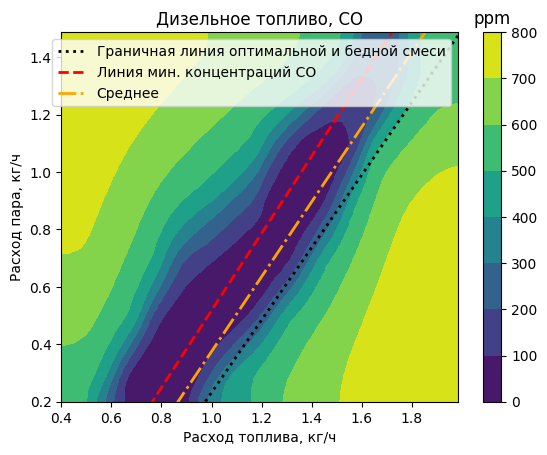

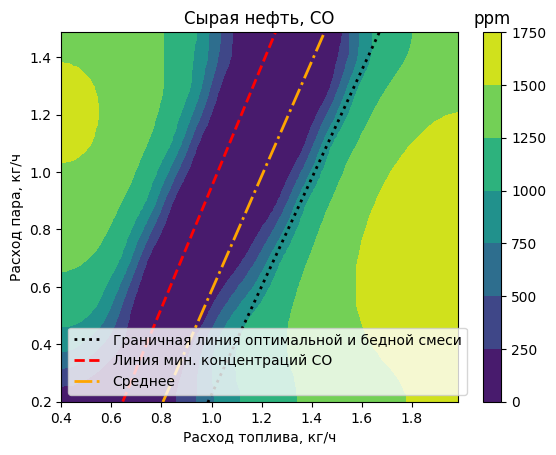

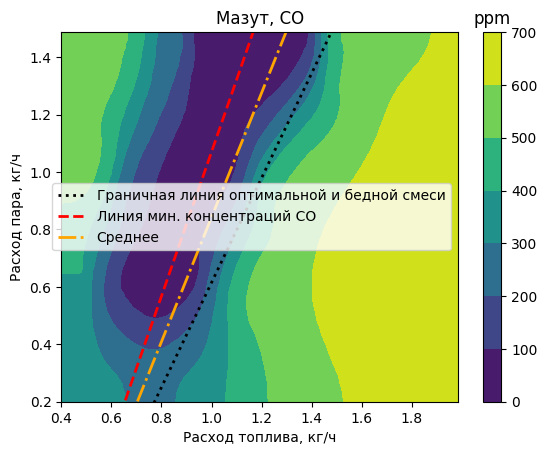

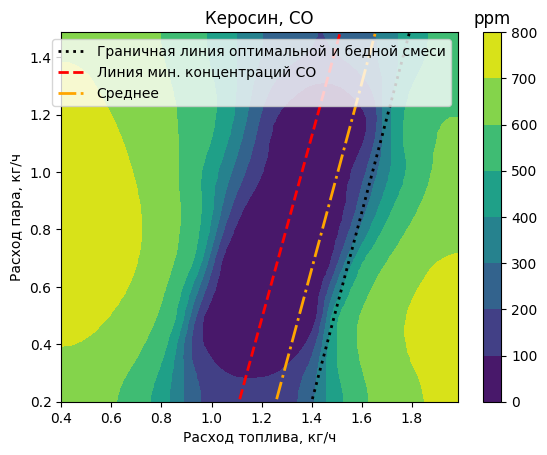

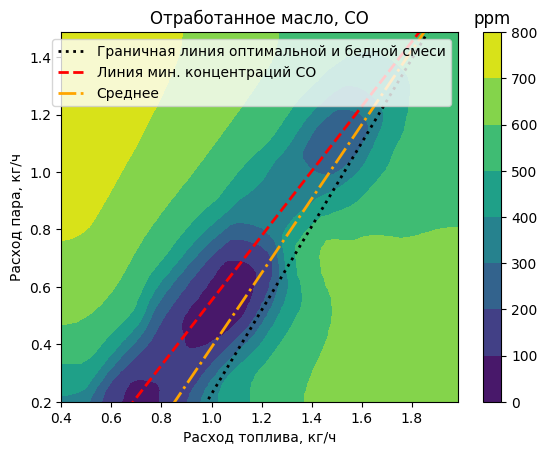

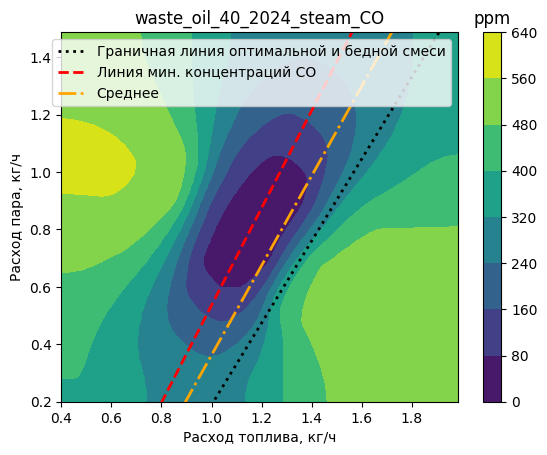

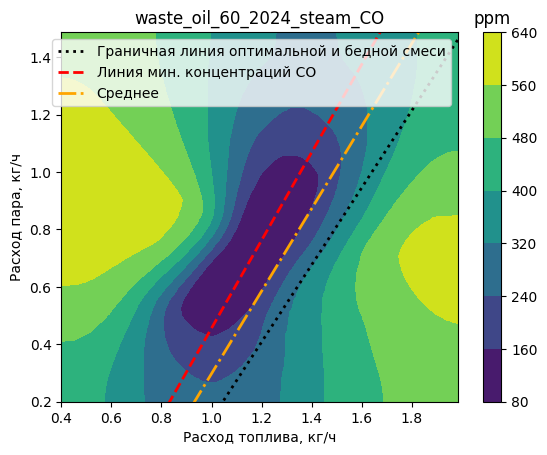

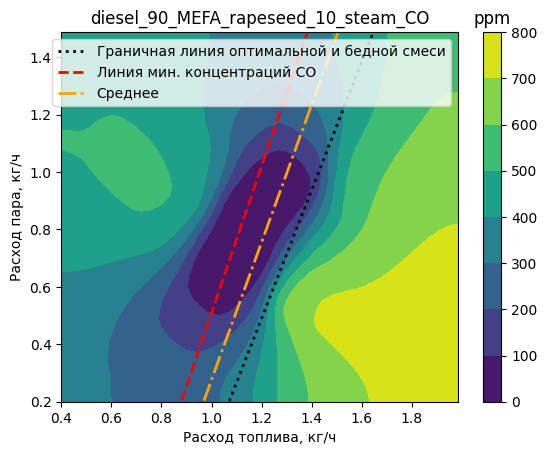

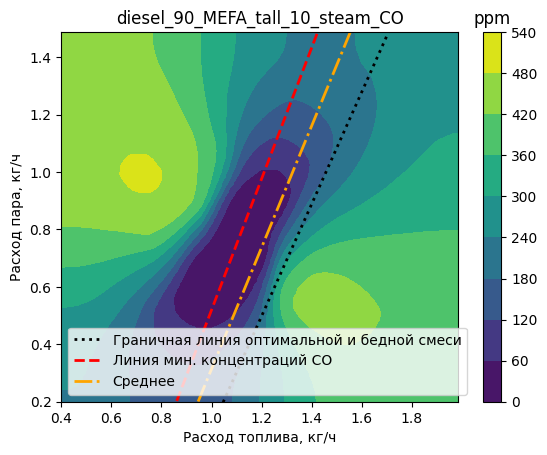

In [5]:
rbf_data = get_rbf_data()
min_CO_coeffs = get_linear_coeffs_min_CO()
diff_data = get_diff_data()
div_line_coeffs_high_line = get_linear_coeffs_div_line(diff_data, 3)
mean_coeffs = get_mean_coeffs(div_line_coeffs_high_line, min_CO_coeffs)

for fuel_combination in rbf_data:
    fuel_cons, add_cons_diff, diff = rbf_data[fuel_combination]
    grad_approx = _linear(fuel_cons, *div_line_coeffs_high_line[fuel_combination])
    min_approx = _linear(fuel_cons, *min_CO_coeffs[fuel_combination])
    mean_approx = _linear(fuel_cons, *mean_coeffs[fuel_combination])
    
    fig, ax = plt.subplots()
    plt.contourf(fuel_cons, add_cons_diff, diff)
    plt.plot(fuel_cons, grad_approx, c='black', linestyle='dotted', linewidth=2, label='Граничная линия оптимальной и бедной смеси')
    plt.plot(fuel_cons, min_approx, c='red', linestyle='dashed', linewidth=2, label='Линия мин. концентраций CO')
    plt.plot(fuel_cons, mean_approx, c='orange', linestyle='dashdot', linewidth=2, label='Среднее')
    clb = plt.colorbar()
    clb.ax.set_title('ppm')
    ax.set_xlabel('Расход топлива, кг/ч')
    ax.set_ylabel('Расход пара, кг/ч')
    plt.legend()
    plt.ylim(min(add_cons_diff), max(add_cons_diff))
    plt.title(title_on_russian(fuel_combination))
    plt.show()
    plt.close()

In [7]:
def mm2s_to_mpas(nu_mm2s, density_kg_m3):
    """
    Конвертация кинематической вязкости из мм²/с в мПа·с
    с использованием плотности в кг/м³.

    :param nu_mm2s: кинематическая вязкость, мм²/с
    :param density_kg_m3: плотность, кг/м³ (по умолчанию 1000 для воды)
    :return: динамическая вязкость, мПа·с
    """
    return nu_mm2s * density_kg_m3 / 1000


MEFA_tall_visc = mm2s_to_mpas(3.8, 735)
MEFA_repeseed_visc = mm2s_to_mpas(3.54, 751)

print(f'diesel_90_MEFA_rapeseed_10 = {MEFA_tall_visc} мПа*с')
print(f'diesel_90_MEFA_tall_10 = {MEFA_repeseed_visc} мПа*с')

diesel_90_MEFA_rapeseed_10 = 2.793 мПа*с
diesel_90_MEFA_tall_10 = 2.65854 мПа*с


In [8]:
def get_viscosity(fuel_combination: FuelCombination) -> float:
    """Динамическая вязкость топлива, mPa*s"""
    viscosity = {
        'diesel_steam_CO': 3.44,  # Химический анализ
        'crude_oil_steam_CO': 5.14,  # Химический анализ
        'heavy_oil_steam_CO': 50,  # Химический анализ                                                                     !!! ПРЕДЫДУЩЕЕ ЗАНЧЕНИЕ - 116.78
        'kerosene_steam_CO': 1.49,  # http://thermalinfo.ru/svojstva-zhidkostej/toplivo-i-masla/plotnost-kerosina-ego-teploemkost-i-vyazkost
        'waste_oil_steam_CO': 125.82,  # Измерено с помощью экспериментальной установки
        'waste_oil_40_2024_steam_CO': 49.34,  # Измерено с помощью экспериментальной установки
        'waste_oil_60_2024_steam_CO': 23.54,  # Измерено с помощью экспериментальной установки
        
        'diesel_90_MEFA_rapeseed_10_steam_CO': 2.65854,
        'diesel_90_MEFA_tall_10_steam_CO': 2.793
    }
    if fuel_combination not in viscosity:
        raise fuel_combination_key_error() 
    return viscosity[fuel_combination]

def get_surface_tension(fuel_combination: FuelCombination) -> float:
    """Поверхностное натяжение топлива, mN/m"""
    surface_tension = {
        'diesel_steam_CO': 30.8,  # поверхностное натяжение: https://additive.spb.ru/surface-tension.html
        'crude_oil_steam_CO': 28,  # Из диплома https://studfile.net/preview/8954587/page:7/
        'heavy_oil_steam_CO': 30,  # https://mostoplivo.ru/mazut/ МАЗУТ БЫЛ ПРИ 80 ГРАДУСАХ                                !!! ПРЕДЫДУЩЕЕ ЗАНЧЕНИЕ - 40
        'kerosene_steam_CO': 26.6,  # поверхностное натяжение: https://additive.spb.ru/surface-tension.html
        'waste_oil_steam_CO': 26.6,  # Измерено при помощи экспериментальной установки
        'waste_oil_40_2024_steam_CO': 26.6,
        'waste_oil_60_2024_steam_CO': 26.6,

        'diesel_90_MEFA_rapeseed_10_steam_CO': 27.5,
        'diesel_90_MEFA_tall_10_steam_CO': 26.8
    }
    
    if fuel_combination not in surface_tension:
        raise fuel_combination_key_error() 
    return surface_tension[fuel_combination]

def get_density(fuel_combination: FuelCombination) -> float:
    """Плотность топлива, kg/m^3"""
    density = {
        'diesel_steam_CO': 839.89,  # Химический анализ
        'crude_oil_steam_CO': 815.61,  # Химический анализ
        'heavy_oil_steam_CO': 890,  # МАЗУТ БЫЛ ПРИ 80 ГРАДУСАХ (значение линейной эксраполяции 15С-20С)                 !!! ПРЕДЫДУЩЕЕ ЗАНЧЕНИЕ - 916.64
        'kerosene_steam_CO': 788.89,  # Химический анализ
        'waste_oil_steam_CO': 920,  # Экспериментальные данные
        'waste_oil_40_2024_steam_CO': 899.9,  # Экспериментальные данные
        'waste_oil_60_2024_steam_CO': 879.2,  # Экспериментальные данные

        'diesel_90_MEFA_rapeseed_10_steam_CO': 751,
        'diesel_90_MEFA_tall_10_steam_CO': 735
    }
    if fuel_combination not in density:
        raise fuel_combination_key_error() 
    return density[fuel_combination]


In [9]:
def get_laplas_numbers(fuel_combination: FuelCombination) -> float:
    surface_tension = get_surface_tension(fuel_combination)
    droplet_size = 2e-3
    viscosity = get_viscosity(fuel_combination)
    density = get_density(fuel_combination)
    
    laplas_number = (2 * droplet_size*density*surface_tension*1e3) / viscosity**2
        
    return laplas_number


for fuel_combination in rbf_data:
    print(f'Число Лапласа {fuel_combination} = {np.round(get_laplas_numbers(fuel_combination), 5)}')

Число Лапласа diesel_steam_CO = 8744.1225
Число Лапласа crude_oil_steam_CO = 3457.59663
Число Лапласа heavy_oil_steam_CO = 42.72
Число Лапласа kerosene_steam_CO = 37808.15999
Число Лапласа waste_oil_steam_CO = 6.18344
Число Лапласа waste_oil_40_2024_steam_CO = 39.33124
Число Лапласа waste_oil_60_2024_steam_CO = 168.81708
Число Лапласа diesel_90_MEFA_rapeseed_10_steam_CO = 11688.16205
Число Лапласа diesel_90_MEFA_tall_10_steam_CO = 10100.43907


In [10]:
mean_coeffs = get_mean_coeffs(div_line_coeffs_high_line, min_CO_coeffs)
mean_coeffs

{'diesel_steam_CO': (1.3037643574027675, -0.9287474646365108),
 'crude_oil_steam_CO': (1.9963687805021144, -1.4094528506022217),
 'heavy_oil_steam_CO': (2.1681891761835104, -1.3254623262768939),
 'kerosene_steam_CO': (3.238883651460582, -3.8712235055786124),
 'waste_oil_steam_CO': (1.2931158745770064, -0.903180032163054),
 'waste_oil_40_2024_steam_CO': (1.5618212854242568, -1.1991902254497036),
 'waste_oil_60_2024_steam_CO': (1.4376541376374838, -1.1395843687553042),
 'diesel_90_MEFA_rapeseed_10_steam_CO': (2.3969832626179386,
  -2.120369419579582),
 'diesel_90_MEFA_tall_10_steam_CO': (2.118310985692238, -1.8041830124249647)}

C:\Users\evils\AppData\Local\Temp\ipykernel_15352\2021647227.py:196: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


Аппроксимация a_mean: y = 0.00004 * x + 1.60442


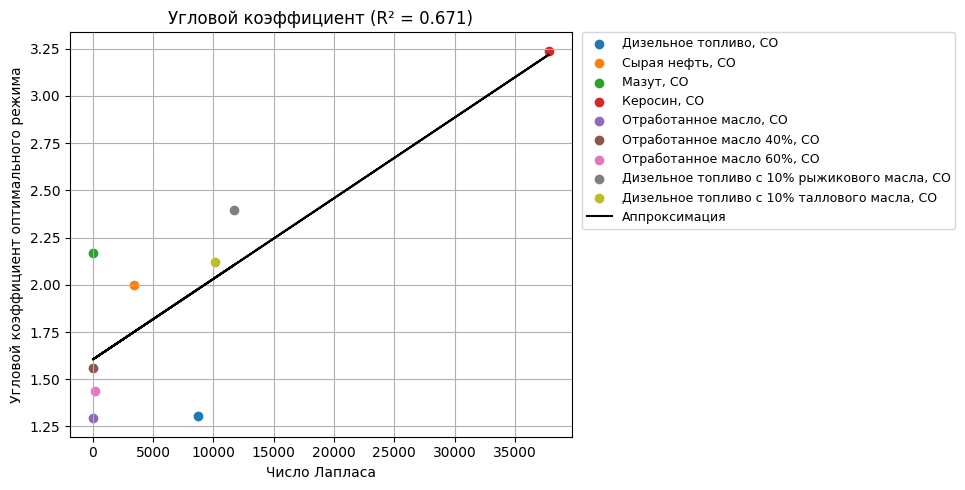

Аппроксимация b_mean: y = -0.00007 * x + -1.05684


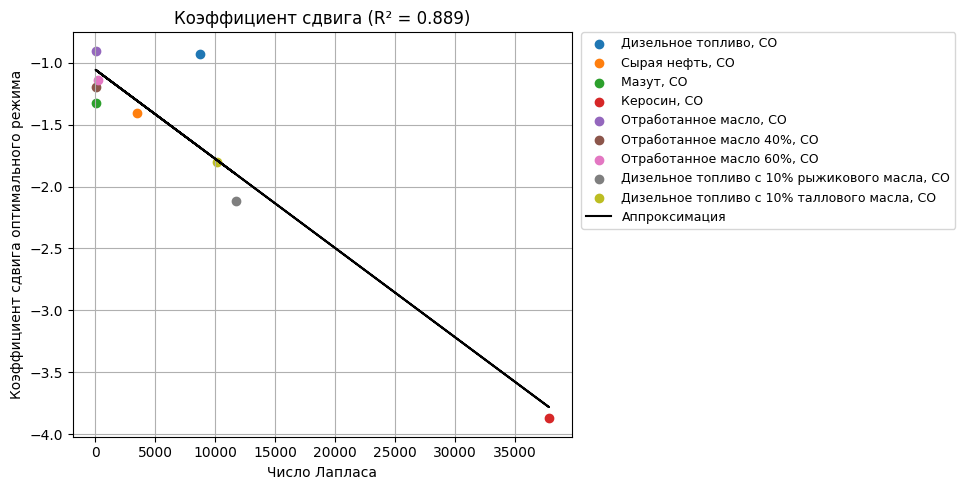

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Переключатель языка: "ru" или "en"
LANG = "ru"  # ← поменяй на "en", чтобы всё стало по-английски

# ======== СЛОВАРЬ ПЕРЕВОДОВ ========
translate = {
    'diesel': {'ru': 'Дизельное топливо', 'en': 'Diesel fuel'},
    'diesel_steam_CO': {'ru': 'Дизельное топливо, CO', 'en': 'Diesel fuel, CO'},
    'crude_oil_steam_CO': {'ru': 'Сырая нефть, CO', 'en': 'Crude oil, CO'},
    'heavy_oil_steam_CO': {'ru': 'Мазут, CO', 'en': 'Heavy oil, CO'},
    'kerosene_steam_CO': {'ru': 'Керосин, CO', 'en': 'Kerosene, CO'},
    'waste_oil_steam_CO': {'ru': 'Отработанное масло, CO', 'en': 'Waste oil, CO'},
    'waste_oil_40_2024_steam_CO': {'ru': 'Отработанное масло 40%, CO', 'en': 'Waste oil 40%, CO'},
    'waste_oil_60_2024_steam_CO': {'ru': 'Отработанное масло 60%, CO', 'en': 'Waste oil 60%, CO'},
    'diesel_90_MEFA_rapeseed_10_steam_CO': {
        'ru': 'Дизельное топливо с 10% рыжикового масла, CO',
        'en': 'Diesel fuel with 10% camelina oil, CO'
    },
    'diesel_90_MEFA_tall_10_steam_CO': {
        'ru': 'Дизельное топливо с 10% таллового масла, CO',
        'en': 'Diesel fuel with 10% tall oil, CO'
    }
}

# ======== ФУНКЦИИ ========

def translate_fuel(fuel_key: str) -> str:
    """Возвращает перевод названия топлива с учетом LANG"""
    # Если есть точное совпадение — вернуть перевод
    if fuel_key in translate:
        return translate[fuel_key][LANG]
    # Если не найдено — попробовать частичное совпадение
    for key in translate:
        if key in fuel_key:
            return translate[key][LANG]
    # Если не нашли — вернуть оригинал
    return fuel_key

def t(ru: str, en: str):
    """Перевод интерфейсных подписей"""
    return ru if LANG == "ru" else en


# ====== Основная часть кода ======
min_CO_coeffs = get_linear_coeffs_min_CO()
diff_data = get_diff_data()
div_line_coeffs_high_line = get_linear_coeffs_div_line(diff_data, 3)
mean_coeffs = get_mean_coeffs(div_line_coeffs_high_line, min_CO_coeffs)

a_mean = {k: v[0] for k, v in mean_coeffs.items()}
b_mean = {k: v[1] for k, v in mean_coeffs.items()}

# --- График a_mean ---
x_vals = [get_laplas_numbers(k) for k in mean_coeffs]
y_vals_a = [a_mean[k] for k in mean_coeffs]
labels = list(mean_coeffs.keys())

coeffs_a = np.polyfit(x_vals, y_vals_a, deg=1)
poly_a = np.poly1d(coeffs_a)
y_pred_a = poly_a(x_vals)

print(t(
    f"Аппроксимация a_mean: y = {coeffs_a[0]:.5f} * x + {coeffs_a[1]:.5f}",
    f"Approximation a_mean: y = {coeffs_a[0]:.5f} * x + {coeffs_a[1]:.5f}"
))

# R²
ss_res_a = np.sum((np.array(y_vals_a) - y_pred_a) ** 2)
ss_tot_a = np.sum((np.array(y_vals_a) - np.mean(y_vals_a)) ** 2)
r2_a = 1 - ss_res_a / ss_tot_a

plt.figure(figsize=(12, 5))  # ← шире, было (8, 5)

for i, fuel_key in enumerate(labels):
    plt.scatter(x_vals[i], y_vals_a[i], label=translate_fuel(fuel_key))

plt.plot(x_vals, y_pred_a, color='black', label=t('Аппроксимация', 'Approximation'))
plt.title(t(f'Угловой коэффициент (R² = {r2_a:.3f})', f'Slope coefficient (R² = {r2_a:.3f})'))
plt.xlabel(t('Число Лапласа', 'Laplace number'))
plt.ylabel(t('Угловой коэффициент оптимального режима', 'Slope coefficient of optimal mode'))
plt.grid(True)

# Легенда справа от графика
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=9)

# Немного сжимаем рисунок, чтобы легенда влезла
plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.show()


# --- График b_mean ---
y_vals_b = [b_mean[k] for k in mean_coeffs]
coeffs_b = np.polyfit(x_vals, y_vals_b, deg=1)
poly_b = np.poly1d(coeffs_b)
y_pred_b = poly_b(x_vals)

print(t(
    f"Аппроксимация b_mean: y = {coeffs_b[0]:.5f} * x + {coeffs_b[1]:.5f}",
    f"Approximation b_mean: y = {coeffs_b[0]:.5f} * x + {coeffs_b[1]:.5f}"
))

ss_res_b = np.sum((np.array(y_vals_b) - y_pred_b) ** 2)
ss_tot_b = np.sum((np.array(y_vals_b) - np.mean(y_vals_b)) ** 2)
r2_b = 1 - ss_res_b / ss_tot_b

plt.figure(figsize=(12, 5))

for i, fuel_key in enumerate(labels):
    plt.scatter(x_vals[i], y_vals_b[i], label=translate_fuel(fuel_key))

plt.plot(x_vals, y_pred_b, color='black', label=t('Аппроксимация', 'Approximation'))
plt.title(t(f'Коэффициент сдвига (R² = {r2_b:.3f})', f'Offset coefficient (R² = {r2_b:.3f})'))
plt.xlabel(t('Число Лапласа', 'Laplace number'))
plt.ylabel(t('Коэффициент сдвига оптимального режима', 'Offset coefficient of optimal mode'))
plt.grid(True)

plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=9)
plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.show()
